# Box Box Box EDA

This notebook is structured from basic profiling to deeper strategy diagnostics.

Goals:
- verify data quality,
- separate categorical and numerical variables,
- inspect imbalance, outliers, and covariate coverage,
- study feature interactions with finish rank,
- decide what belongs in a ranking model.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'analysis' else Path.cwd().resolve()
CSV_PATH = ROOT / 'analysis' / 'historical_driver_features.csv'

if not CSV_PATH.exists():
    import subprocess
    subprocess.run(['python', str(ROOT / 'analysis' / 'build_dataset.py')], check=True)

df = pd.read_csv(CSV_PATH)
df.head()

,race_id,grid_slot,driver_id,track,total_laps,base_lap_time,pit_lane_time,track_temp,starting_tire,pit_stop_count,...,medium_max_stint,hard_laps,hard_stints,hard_max_stint,stint_1_compound,stint_1_laps,stint_2_compound,stint_2_laps,stint_3_compound,stint_3_laps
0,R21072,pos1,D001,Suzuka,50,84.5,22.7,27,MEDIUM,1,...,23,27,1,27,MEDIUM,23,HARD,27,NaN,0
1,R21072,pos10,D010,Suzuka,50,84.5,22.7,27,SOFT,2,...,0,23,1,23,SOFT,11,HARD,23,SOFT,16
2,R21072,pos11,D011,Suzuka,50,84.5,22.7,27,MEDIUM,1,...,20,0,0,0,MEDIUM,20,SOFT,30,NaN,0
3,R21072,pos12,D012,Suzuka,50,84.5,22.7,27,HARD,2,...,0,34,2,18,HARD,16,SOFT,16,HARD,18
4,R21072,pos13,D013,Suzuka,50,84.5,22.7,27,MEDIUM,1,...,26,0,0,0,MEDIUM,26,SOFT,24,NaN,0


In [2]:
categorical_cols = [
    'track', 'starting_tire', 'tire_sequence',
    'stint_1_compound', 'stint_2_compound', 'stint_3_compound'
]
numeric_cols = [
    'total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp',
    'pit_stop_count', 'first_stop_lap', 'second_stop_lap', 'stint_count',
    'soft_laps', 'soft_stints', 'soft_max_stint',
    'medium_laps', 'medium_stints', 'medium_max_stint',
    'hard_laps', 'hard_stints', 'hard_max_stint',
    'stint_1_laps', 'stint_2_laps', 'stint_3_laps',
    'finish_rank', 'finish_rank_pct'
]

schema_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'n_unique': df.nunique(dropna=False),
})

print('shape:', df.shape)
print('duplicate rows:', df.duplicated().sum())
print('races:', df['race_id'].nunique())
print('drivers per race min/max:', df.groupby('race_id')['driver_id'].nunique().min(), df.groupby('race_id')['driver_id'].nunique().max())
display(schema_summary.loc[categorical_cols + numeric_cols])

shape: (600000, 31)
duplicate rows: 0
races: 30000
drivers per race min/max: 20 20


,dtype,missing,n_unique
track,object,0,7
starting_tire,object,0,3
tire_sequence,object,0,18
stint_1_compound,object,0,3
stint_2_compound,object,0,3
stint_3_compound,object,546021,4
total_laps,int64,0,46
base_lap_time,float64,0,151
pit_lane_time,float64,0,41
track_temp,int64,0,23


In [3]:
race_level = df.groupby('race_id').agg(
    drivers=('driver_id', 'nunique'),
    tracks=('track', 'nunique'),
    total_laps=('total_laps', 'first'),
    track_temp=('track_temp', 'first')
).reset_index()

display(race_level.describe())
display(df['finish_rank'].value_counts().sort_index().to_frame('count').head(20))

,drivers,tracks,total_laps,track_temp
count,30000.0,30000.0,30000.000000,30000.000000
mean,20.0,1.0,45.516633,30.305467
std,0.0,0.0,10.365194,4.579002
min,20.0,1.0,25.000000,18.000000
25%,20.0,1.0,38.000000,28.000000
50%,20.0,1.0,45.000000,30.000000
75%,20.0,1.0,52.000000,33.000000
max,20.0,1.0,70.000000,42.000000


,count
finish_rank,
1,30000
2,30000
3,30000
4,30000
5,30000
6,30000
7,30000
8,30000
9,30000


In [4]:
for col in categorical_cols:
    print(f'\nTop levels for {col}:')
    display(df[col].value_counts(dropna=False).head(12).to_frame('count'))


Top levels for track:


,count
track,
Monza,86800
Spa,86600
Bahrain,86460
Monaco,86000
Suzuka,84780
COTA,84700
Silverstone,84660



Top levels for starting_tire:


,count
starting_tire,
HARD,202921
MEDIUM,202492
SOFT,194587



Top levels for tire_sequence:


...

,count
stint_1_compound,
HARD,202921
MEDIUM,202492
SOFT,194587



Top levels for stint_2_compound:


,count
stint_2_compound,
HARD,230891
MEDIUM,194599
SOFT,174510



Top levels for stint_3_compound:


,count
stint_3_compound,
NaN,546021
MEDIUM,18201
SOFT,17922
HARD,17856


In [5]:
display(df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
total_laps,600000.0,45.516633,10.365029,25.0,25.0,28.00,38.00,45.0,52.00,65.00,70.0,70.0
base_lap_time,600000.0,87.500643,4.336187,80.0,80.2,80.70,83.70,87.5,91.30,94.30,94.9,95.0
pit_lane_time,600000.0,21.999900,1.157111,20.0,20.0,20.20,21.00,22.0,23.00,23.80,24.0,24.0
track_temp,600000.0,30.305467,4.578929,18.0,18.0,21.00,28.00,30.0,33.00,39.00,42.0,42.0
pit_stop_count,600000.0,1.089965,0.286132,1.0,1.0,1.00,1.00,1.0,1.00,2.00,2.0,2.0
first_stop_lap,600000.0,20.627585,9.575811,6.0,6.0,8.00,13.00,18.0,27.00,39.00,42.0,45.0
second_stop_lap,53979.0,36.082829,8.706362,20.0,21.0,23.00,29.00,35.0,42.00,52.00,57.0,60.0
stint_count,600000.0,2.089965,0.286132,2.0,2.0,2.00,2.00,2.0,2.00,3.00,3.0,3.0
soft_laps,600000.0,9.779958,10.271182,0.0,0.0,0.00,0.00,8.0,15.00,31.00,40.0,57.0
soft_stints,600000.0,0.645032,0.508792,0.0,0.0,0.00,0.00,1.0,1.00,1.00,2.0,2.0


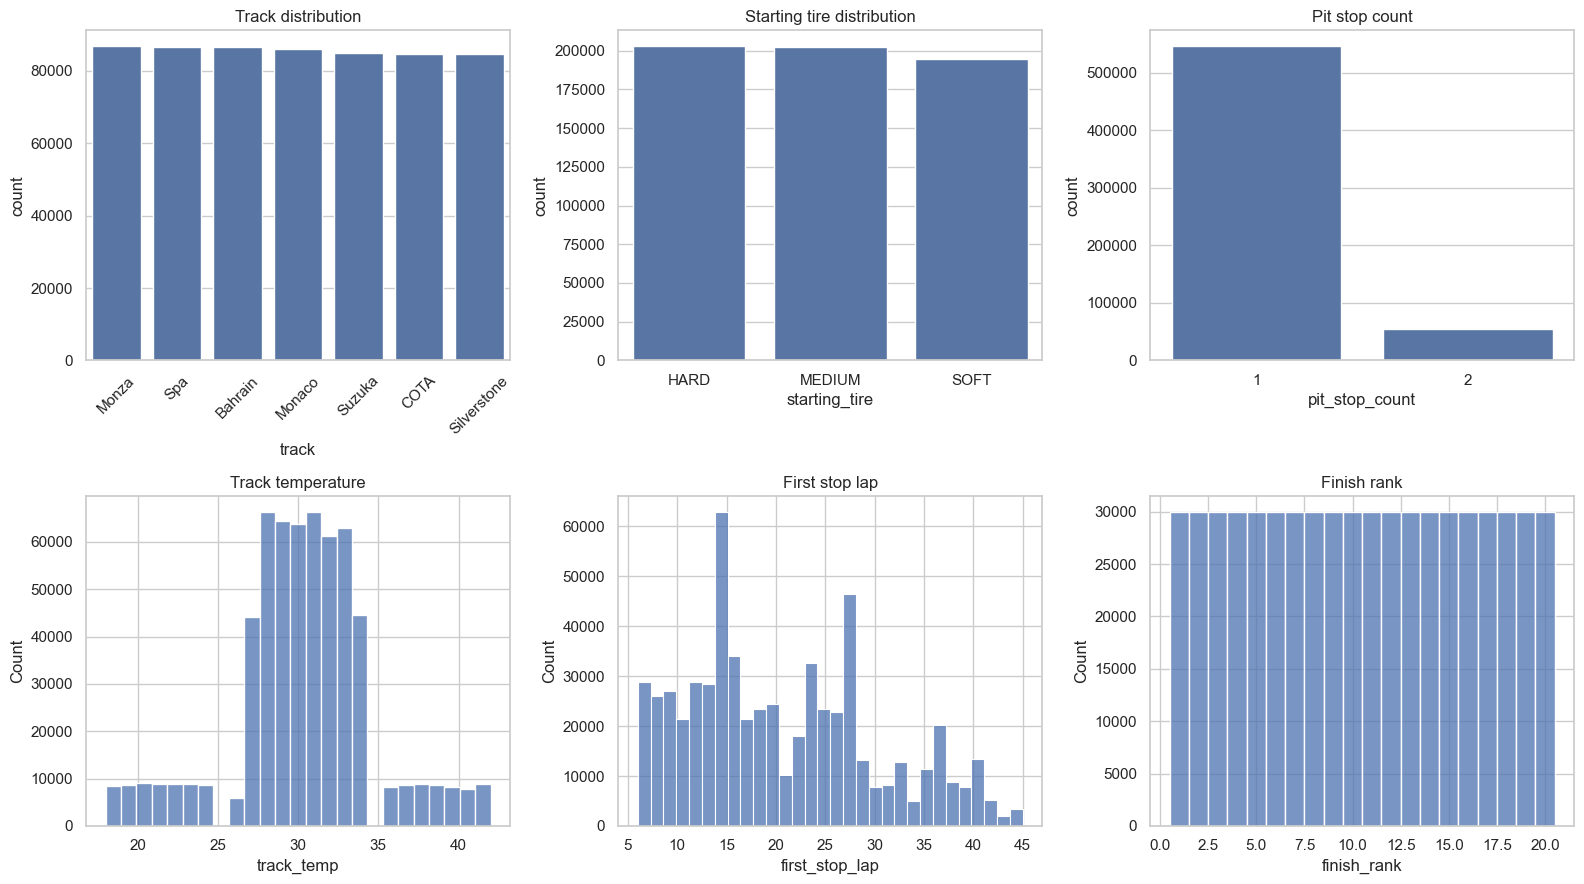

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(data=df, x='track', order=df['track'].value_counts().index, ax=axes[0, 0])
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_title('Track distribution')

sns.countplot(data=df, x='starting_tire', order=df['starting_tire'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Starting tire distribution')

sns.countplot(data=df, x='pit_stop_count', ax=axes[0, 2])
axes[0, 2].set_title('Pit stop count')

sns.histplot(data=df, x='track_temp', bins=25, ax=axes[1, 0])
axes[1, 0].set_title('Track temperature')

sns.histplot(data=df, x='first_stop_lap', bins=30, ax=axes[1, 1])
axes[1, 1].set_title('First stop lap')

sns.histplot(data=df, x='finish_rank', bins=20, discrete=True, ax=axes[1, 2])
axes[1, 2].set_title('Finish rank')

plt.tight_layout()

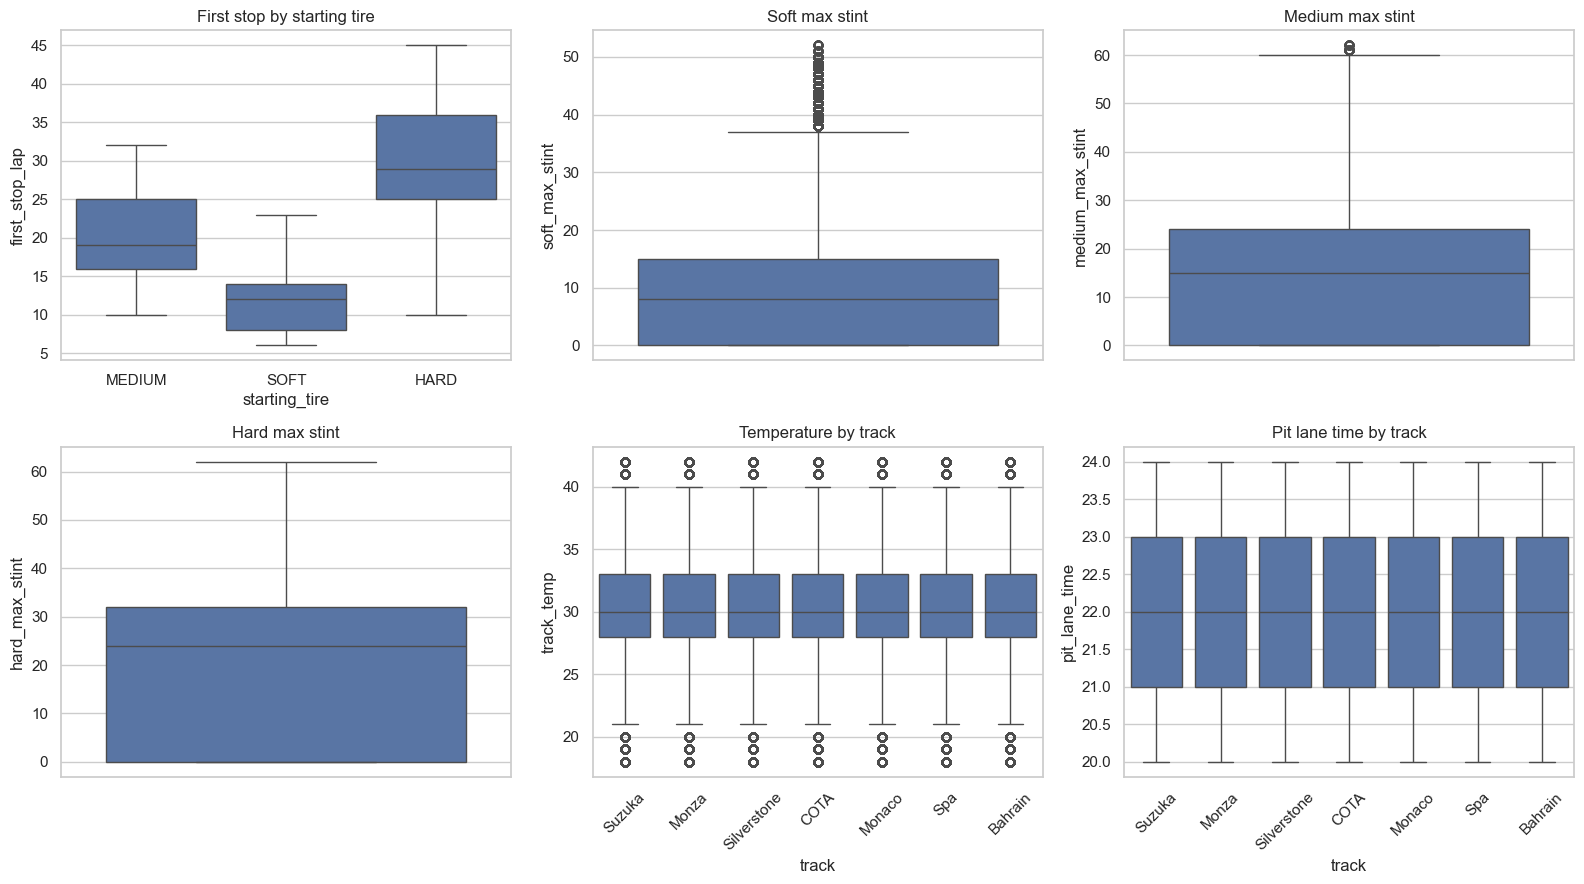

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.boxplot(data=df, y='first_stop_lap', x='starting_tire', ax=axes[0, 0])
axes[0, 0].set_title('First stop by starting tire')

sns.boxplot(data=df, y='soft_max_stint', ax=axes[0, 1])
axes[0, 1].set_title('Soft max stint')

sns.boxplot(data=df, y='medium_max_stint', ax=axes[0, 2])
axes[0, 2].set_title('Medium max stint')

sns.boxplot(data=df, y='hard_max_stint', ax=axes[1, 0])
axes[1, 0].set_title('Hard max stint')

sns.boxplot(data=df, y='track_temp', x='track', ax=axes[1, 1])
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_title('Temperature by track')

sns.boxplot(data=df, y='pit_lane_time', x='track', ax=axes[1, 2])
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].set_title('Pit lane time by track')

plt.tight_layout()

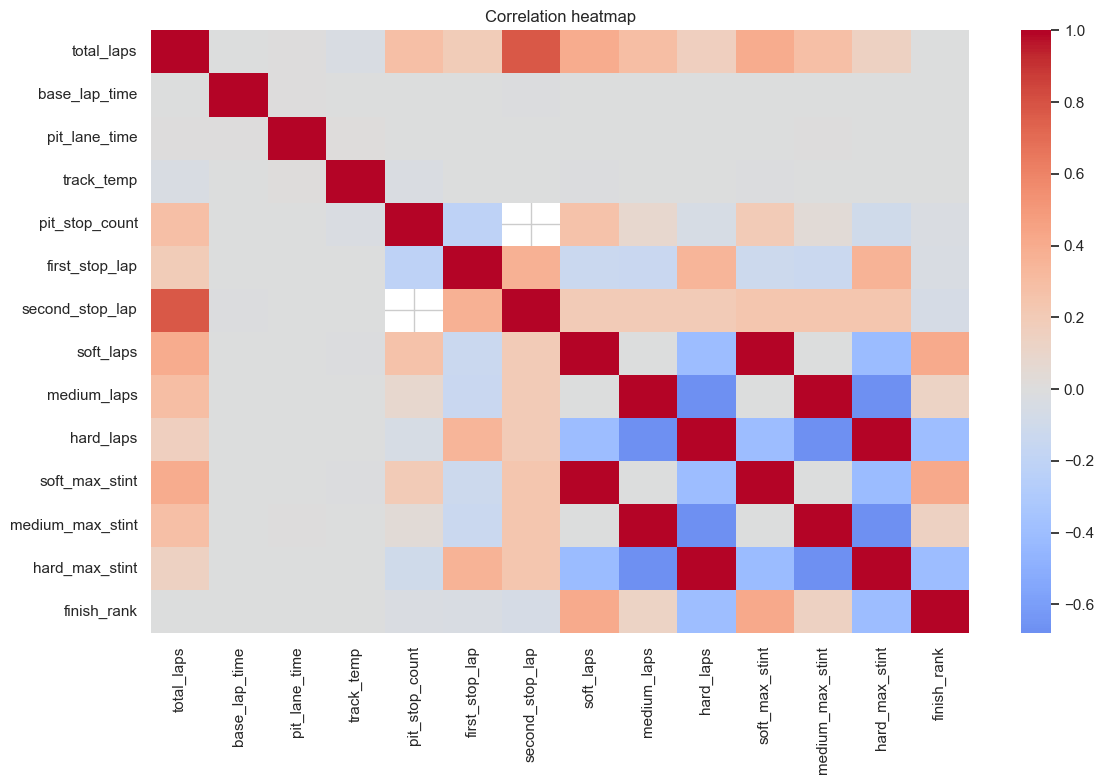

In [8]:
corr_cols = [
    'total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp',
    'pit_stop_count', 'first_stop_lap', 'second_stop_lap',
    'soft_laps', 'medium_laps', 'hard_laps',
    'soft_max_stint', 'medium_max_stint', 'hard_max_stint',
    'finish_rank'
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[corr_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()

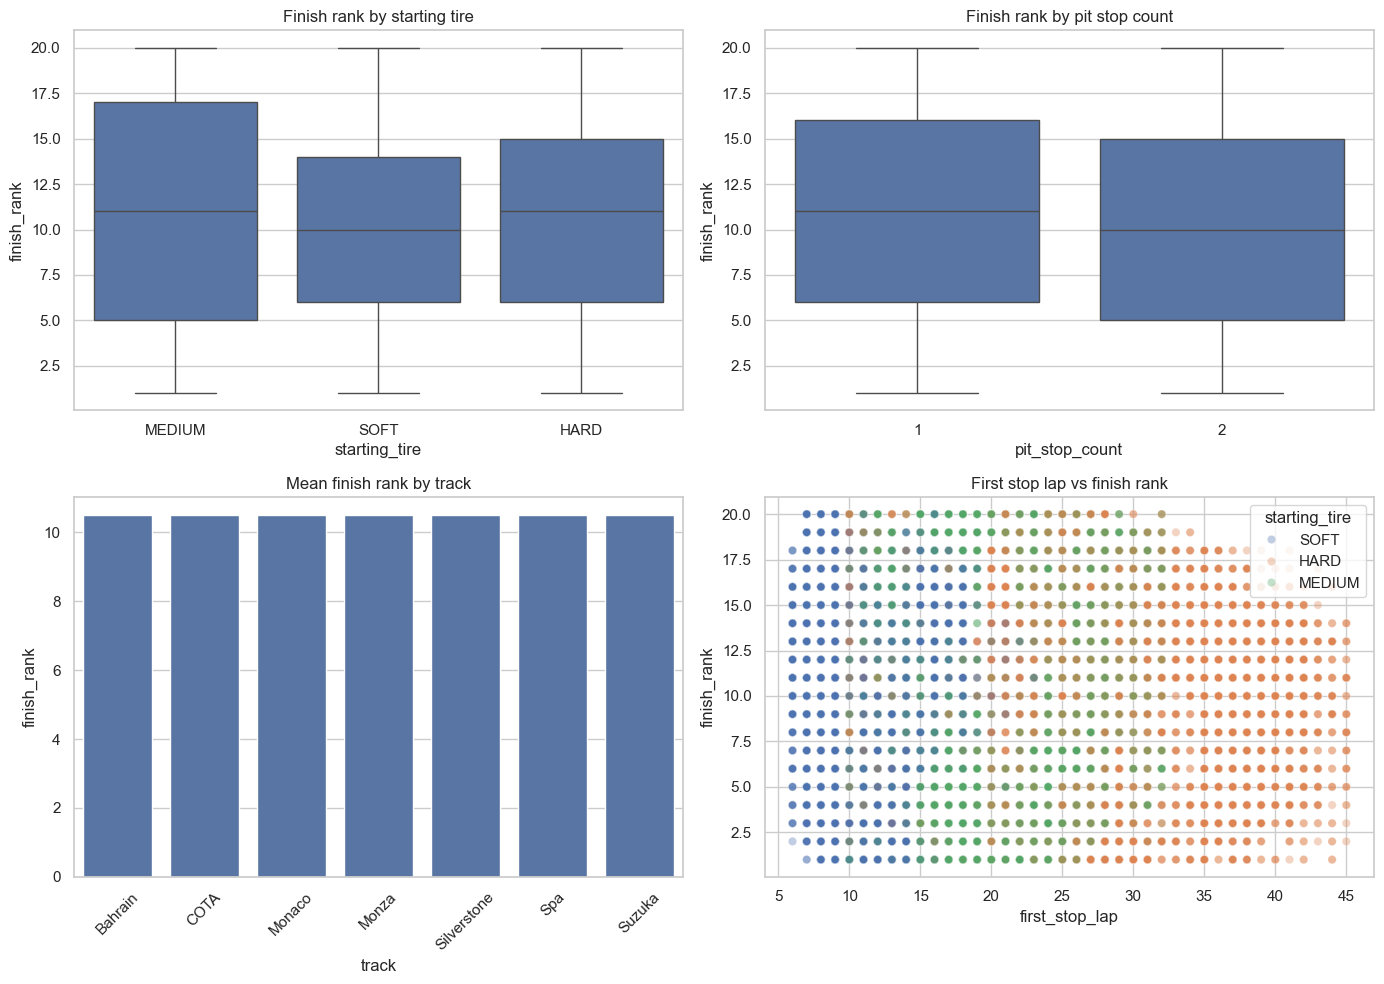

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='starting_tire', y='finish_rank', ax=axes[0, 0])
axes[0, 0].set_title('Finish rank by starting tire')

sns.boxplot(data=df, x='pit_stop_count', y='finish_rank', ax=axes[0, 1])
axes[0, 1].set_title('Finish rank by pit stop count')

track_rank = df.groupby('track', as_index=False)['finish_rank'].mean().sort_values('finish_rank')
sns.barplot(data=track_rank, x='track', y='finish_rank', ax=axes[1, 0])
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_title('Mean finish rank by track')

sns.scatterplot(data=df.sample(20000, random_state=42), x='first_stop_lap', y='finish_rank', hue='starting_tire', alpha=0.35, ax=axes[1, 1])
axes[1, 1].set_title('First stop lap vs finish rank')

plt.tight_layout()

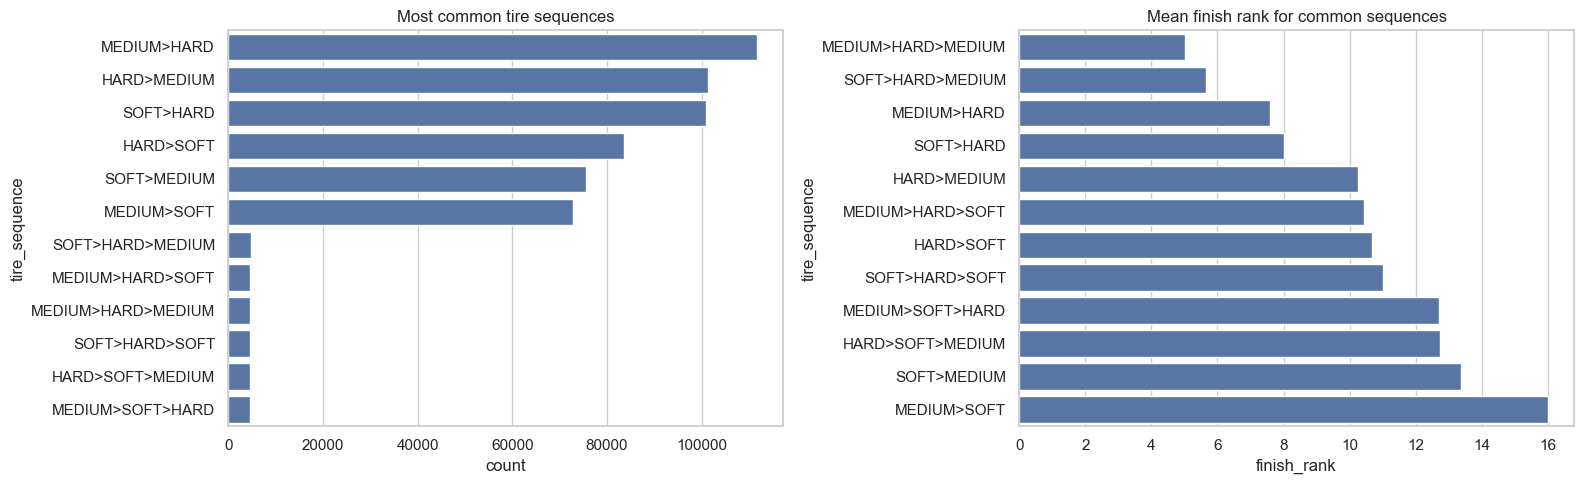

In [10]:
top_sequences = df['tire_sequence'].value_counts().head(12).index
seq_df = df[df['tire_sequence'].isin(top_sequences)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=seq_df, y='tire_sequence', order=top_sequences, ax=axes[0])
axes[0].set_title('Most common tire sequences')

seq_rank = seq_df.groupby('tire_sequence', as_index=False)['finish_rank'].mean().sort_values('finish_rank')
sns.barplot(data=seq_rank, y='tire_sequence', x='finish_rank', ax=axes[1])
axes[1].set_title('Mean finish rank for common sequences')

plt.tight_layout()

pit_stop_count,1,2
starting_tire,,
HARD,10.442718,11.552008
MEDIUM,10.904437,9.879909
SOFT,10.300602,8.487954


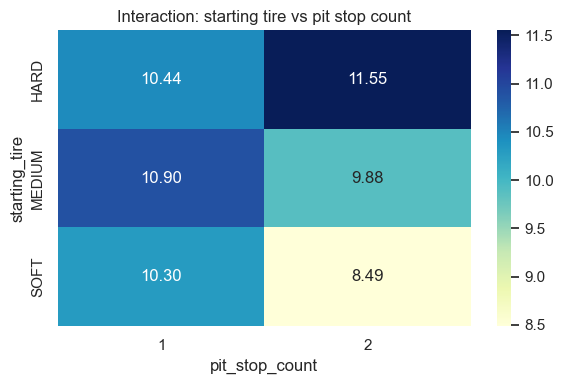

In [11]:
pivot = df.pivot_table(
    values='finish_rank',
    index='starting_tire',
    columns='pit_stop_count',
    aggfunc='mean'
)

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Interaction: starting tire vs pit stop count')
plt.tight_layout()

display(pivot)

In [12]:
test_rows = []
for path in sorted((ROOT / 'data' / 'test_cases' / 'inputs').glob('test_*.json')):
    with path.open() as fh:
        race = json.load(fh)
    rc = race['race_config']
    test_rows.append({
        'track': rc['track'],
        'total_laps': rc['total_laps'],
        'base_lap_time': rc['base_lap_time'],
        'pit_lane_time': rc['pit_lane_time'],
        'track_temp': rc['track_temp'],
    })

test_df = pd.DataFrame(test_rows)
coverage = pd.DataFrame({
    'train_min': df[['total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp']].min(),
    'train_max': df[['total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp']].max(),
    'test_min': test_df[['total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp']].min(),
    'test_max': test_df[['total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp']].max(),
})

display(coverage)
display(test_df['track'].value_counts().to_frame('test_count'))

,train_min,train_max,test_min,test_max
total_laps,25.0,70.0,27.0,69.0
base_lap_time,80.0,95.0,80.1,94.9
pit_lane_time,20.0,24.0,20.1,23.9
track_temp,18.0,42.0,18.0,42.0


,test_count
track,
Monza,19
Suzuka,18
Monaco,16
Bahrain,13
Silverstone,12
Spa,12
COTA,10


## Recommended EDA depth

Basic:
- schema, missingness, duplicates,
- categorical frequency tables,
- numerical distributions,
- outlier checks.

Intermediate:
- correlation heatmap,
- feature vs target plots,
- strategy sequence prevalence,
- interaction heatmaps.

Deeper:
- per-track EDA,
- grouped train/validation splits by race,
- rank-based metrics instead of plain accuracy,
- calibration of a simulator or a grouped ranking model.